In [8]:
#
# First test feynman diagram features
#
import gpt as g
import matplotlib.pyplot as plt
f = g.qcd.feynman

### Operator Warmup

In [2]:
pipi_t0 = f.isospin.pipi("t0,p", "t0,q", 1, 0)
pipi_t1 = f.isospin.pipi("t1,p", "t1,q", 1, 0)
vec0 = f.isospin.pi0("x")
vec1 = f.isospin.pi0("y")

print(f.isospin.multiplet(f.isospin.two_pions("x","y",I=1), f.isospin.pions("z"), I=1))

   |1, 1>:
+ (0.49999999999999983)*e**0 * upbar(x) * down(x) * downbar(y) * up(y) * downbar(z) * up(z)
+ (-0.49999999999999983)*e**0 * downbar(x) * up(x) * upbar(y) * down(y) * downbar(z) * up(z)
+ (0.24999999999999992)*e**0 * upbar(x) * up(x) * downbar(y) * up(y) * upbar(z) * up(z)
+ (-0.24999999999999992)*e**0 * upbar(x) * up(x) * downbar(y) * up(y) * downbar(z) * down(z)
+ (-0.24999999999999992)*e**0 * downbar(x) * down(x) * downbar(y) * up(y) * upbar(z) * up(z)
+ (0.24999999999999992)*e**0 * downbar(x) * down(x) * downbar(y) * up(y) * downbar(z) * down(z)
+ (-0.24999999999999992)*e**0 * downbar(x) * up(x) * upbar(y) * up(y) * upbar(z) * up(z)
+ (0.24999999999999992)*e**0 * downbar(x) * up(x) * upbar(y) * up(y) * downbar(z) * down(z)
+ (0.24999999999999992)*e**0 * downbar(x) * up(x) * downbar(y) * down(y) * upbar(z) * up(z)
+ (-0.24999999999999992)*e**0 * downbar(x) * up(x) * downbar(y) * down(y) * downbar(z) * down(z)
 + |1, 0>:
+ (-0.3535533905932736)*e**0 * upbar(x) * down(x) * u

### Two-pion scattering

0 0


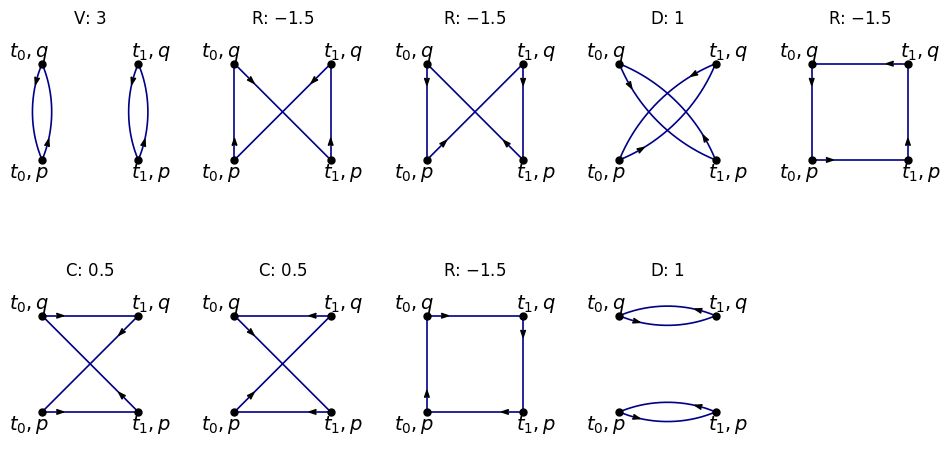

1 0
= 0
1 1


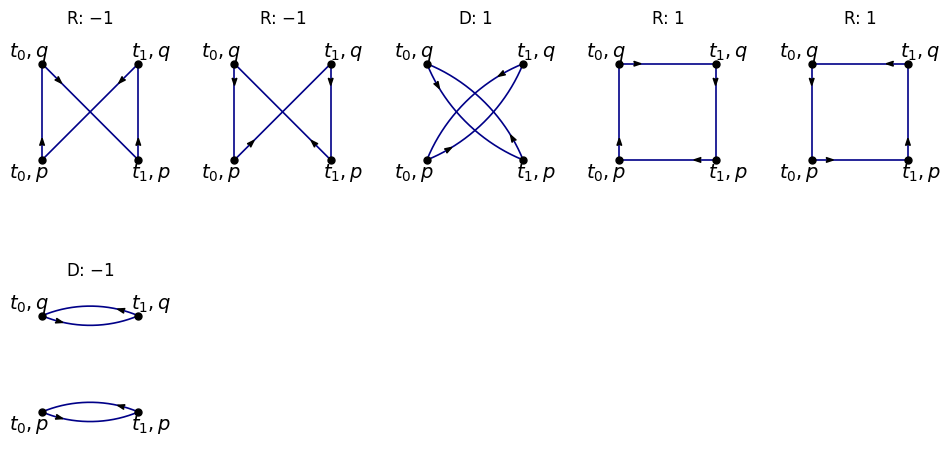

2 0
= 0
2 1
= 0
2 2


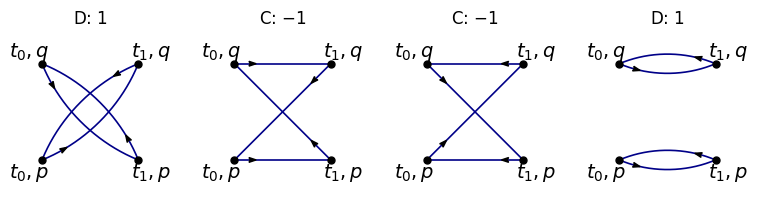

In [3]:
names = {
    "light_t0,p_t0,q/light_t0,q_t0,p/light_t1,p_t1,q/light_t1,q_t1,p" : "V",
    "light_t0,p_t1,q/light_t0,q_t0,p/light_t1,p_t0,q/light_t1,q_t1,p" : "R",
    "light_t0,p_t0,q/light_t0,q_t1,p/light_t1,p_t1,q/light_t1,q_t0,p" : "R",
    "light_t0,p_t1,q/light_t0,q_t1,p/light_t1,p_t0,q/light_t1,q_t0,p" : "D",
    "light_t0,p_t0,q/light_t0,q_t1,q/light_t1,p_t0,p/light_t1,q_t1,p" : "R", 
    "light_t0,p_t1,q/light_t0,q_t1,p/light_t1,p_t0,p/light_t1,q_t0,q" : "C",
    "light_t0,p_t1,p/light_t0,q_t1,q/light_t1,p_t0,q/light_t1,q_t0,p" : "C",
    "light_t0,p_t1,p/light_t0,q_t0,p/light_t1,p_t1,q/light_t1,q_t0,q" : "R",
    "light_t0,p_t1,p/light_t0,q_t1,q/light_t1,p_t0,p/light_t1,q_t0,q" : "D"
}

operators = {
    "t0,p" : (0.2,0.2,"$t_0,p$",-0.08,-0.08),
    "t0,q" : (0.2,0.8,"$t_0,q$",-0.08,0.08),
    "t1,p" : (0.8,0.2,"$t_1,p$",0.08,-0.08),
    "t1,q" : (0.8,0.8,"$t_1,q$",0.08,0.08),
    "x" : (0.8,0.5,"$x$",0.08,0),
    "y" : (0.2,0.5,"$x$",-0.08,0)
}

flavors = {
    "light" : {"color" : "#000088", "stroke" : "single", "flavour" : "simple", "arrow_param" : {"t":0.15}}
}

for I1 in [0,1,2]:
    for I2 in range(I1+1):
        coef = (
            f.contract(f.isospin.pipi("t0,p", "t0,q", I1, 0) * f.isospin.pipi("t1,p", "t1,q", I2, 0))
            .replace("up", "light")
            .replace("down", "light")
            .simplify()
            .coefficients({})
        )
        print(I1, I2)

        if len(coef) == 0:
            print("= 0")
            continue
            
        fig = plt.figure(figsize=(4*3,6))
    
        for i, c in enumerate(coef):
            ax = fig.add_subplot(2, 5, i+1, aspect=1, frameon=False, title=f"{names[c]}: ${coef[c]:g}$")
            f.draw(ax, c, operators, flavors)

        plt.show()
        

### HVP long-distance reconstruction diagrams

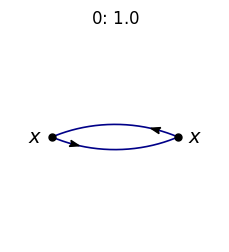

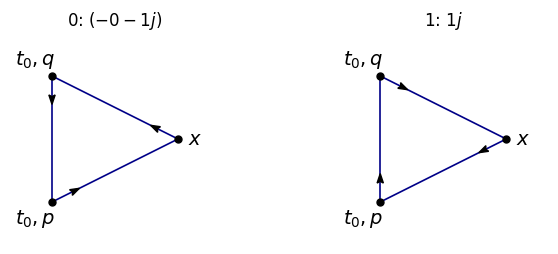

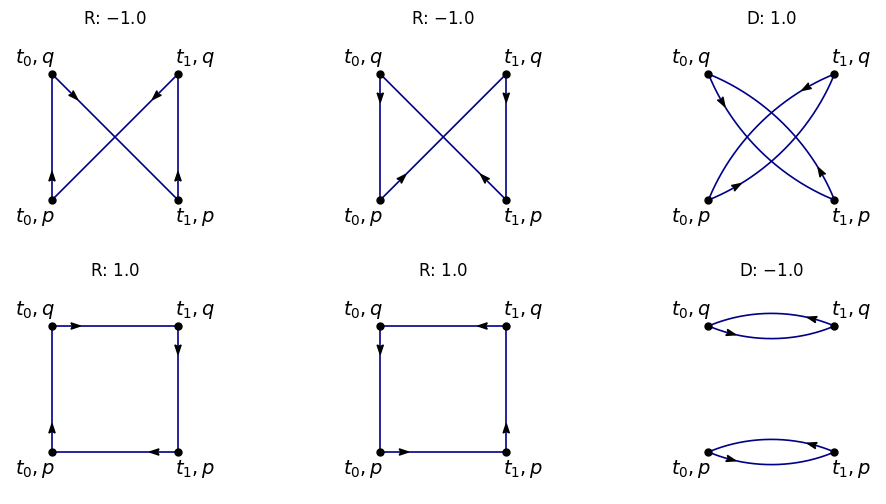

In [4]:
coef = (
    f.contract(vec1 * vec0)
    .replace("up", "light")
    .replace("down", "light")
    .simplify()
    .coefficients({})
)

fig = plt.figure(figsize=(4*3,6))
    
for i, c in enumerate(coef):
    ax = fig.add_subplot(2, 3, i+1, aspect=1, frameon=False, title=f"{i}: ${coef[c]}$")
    f.draw(ax, c, operators, flavors)

plt.savefig("diagsVV.pdf")
plt.show()

coef = (
    f.contract(pipi_t0 * vec0)
    .replace("up", "light")
    .replace("down", "light")
    .simplify()
    .coefficients({})
)


fig = plt.figure(figsize=(4*3,6))
    
for i, c in enumerate(coef):
    ax = fig.add_subplot(2, 3, i+1, aspect=1, frameon=False, title=f"{i}: ${coef[c]}$")
    f.draw(ax, c, operators, flavors)

plt.savefig("diags2PiV.pdf")
plt.show()

coef = (
    f.contract(pipi_t0 * pipi_t1)
    .replace("up", "light")
    .replace("down", "light")
    .simplify()
    .coefficients({})
)


fig = plt.figure(figsize=(4*3,6))
    
for i, c in enumerate(coef):
    ax = fig.add_subplot(2, 3, i+1, aspect=1, frameon=False, title=f"{names[c]}: ${coef[c]}$")
    f.draw(ax, c, operators, flavors)

plt.savefig("diags2Pi2Pi.pdf")
plt.show()

### Full octahedral group representations

In [5]:
minmom = [(1,0,0), (1,1,0), (1,1,1), (2,0,0), (2,1,0), (2,1,1), (2,2,0), (2,2,1), (3,0,0), (3,1,0), (3,1,1), (3,2,1), (7,5,3)]

for mm in minmom:
    rops = g.algorithms.group.full_octahedral.t1u_all(mm, 0)
    print("----",mm,"----")
    for i, r in enumerate(rops):
        print("**",i,"**")
        print(r)

---- (1, 0, 0) ----
** 0 **
   (0.7071067811865475) * O((1, 0, 0))
 + (-0.7071067811865475) * O((-1, 0, 0))

---- (1, 1, 0) ----
** 0 **
   (0.35355339059327373) * O((1, 0, 1))
 + (-0.35355339059327373) * O((-1, 0, 1))
 + (0.35355339059327373) * O((1, 0, -1))
 + (-0.35355339059327373) * O((-1, 0, -1))
 + (0.35355339059327373) * O((1, 1, 0))
 + (-0.35355339059327373) * O((-1, 1, 0))
 + (0.35355339059327373) * O((1, -1, 0))
 + (-0.35355339059327373) * O((-1, -1, 0))

---- (1, 1, 1) ----
** 0 **
   (-0.35355339059327373) * O((-1, 1, -1))
 + (-0.35355339059327373) * O((-1, 1, 1))
 + (-0.35355339059327373) * O((-1, -1, -1))
 + (0.35355339059327373) * O((1, -1, 1))
 + (-0.35355339059327373) * O((-1, -1, 1))
 + (0.35355339059327373) * O((1, -1, -1))
 + (0.35355339059327373) * O((1, 1, -1))
 + (0.35355339059327373) * O((1, 1, 1))

---- (2, 0, 0) ----
** 0 **
   (-0.7071067811865475) * O((-2, 0, 0))
 + (0.7071067811865475) * O((2, 0, 0))

---- (2, 1, 0) ----
** 0 **
   (0.31622776601683794) * O

### Baryons

Proton
+ (-0.40824829046386335)*e**0 * down(x1) * up(x2) * up(x3)
+ (-0.40824829046386335)*e**0 * up(x1) * down(x2) * up(x3)
+ (0.8164965809277256)*e**0 * up(x1) * up(x2) * down(x3)

Neutron
+ (-0.8164965809277266)*e**0 * down(x1) * down(x2) * up(x3)
+ (0.40824829046386224)*e**0 * down(x1) * up(x2) * down(x3)
+ (0.40824829046386224)*e**0 * up(x1) * down(x2) * down(x3)



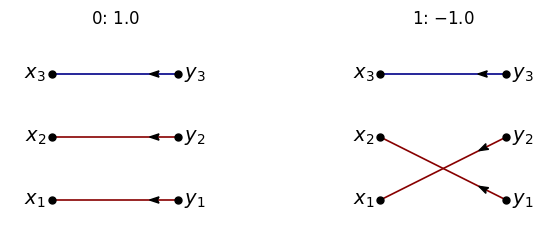

In [13]:
nucleon = f.isospin.multiplet(
    f.isospin.multiplet(f.isospin.quark("x1"), f.isospin.quark("x2"), 1),
    f.isospin.quark("x3"),
    I=1/2
)
print("Proton")
print(nucleon[1/2])

print("Neutron")
print(nucleon[-1/2])

proton = 1j * f.field("up", "x1") * f.field("up", "x2") * f.field("down", "x3")
antiproton = 1j * f.field("upbar", "y1") * f.field("upbar", "y2") * f.field("downbar", "y3")

coef = (
    f.contract(proton * antiproton)
    #.replace("up", "light")
    #.replace("down", "light")
    .simplify()
    .coefficients({})
)

operators = {
    "x1" : (0.2,0.2,"$x_1$",-0.08,0),
    "x2" : (0.2,0.5,"$x_2$",-0.08,0),
    "x3" : (0.2,0.8,"$x_3$",-0.08,0),
    "y1" : (0.8,0.2,"$y_1$",0.08,0),
    "y2" : (0.8,0.5,"$y_2$",0.08,0),
    "y3" : (0.8,0.8,"$y_3$",0.08,0),
}

flavors = {
    "down" : {"color" : "#000088", "stroke" : "single", "flavour" : "simple", "arrow_param" : {"t":0.15}},
    "up" : {"color" : "#880000", "stroke" : "single", "flavour" : "simple", "arrow_param" : {"t":0.15}}
}


fig = plt.figure(figsize=(4*3,6))
    
for i, c in enumerate(coef):
    ax = fig.add_subplot(2, 3, i+1, aspect=1, frameon=False, title=f"{i}: ${coef[c]}$")
    f.draw(ax, c, operators, flavors)

plt.savefig("proton.pdf")
plt.show()



### Moving CGFW momentum combinations

In [7]:
moms = [
    (0,0,0),
    (1,0,0),
    (-1,0,0),
    (0,1,0),
    (0,-1,0),
    (0,0,1),
    (0,0,-1),
    (2,0,0),
    (-2,0,0),
    (0,2,0),
    (0,-2,0),
    (0,0,2),
    (0,0,-2),
    (1,1,1),
    (1,1,-1),
    (1,-1,1),
    (-1,1,1),
    (-1,-1,-1),
    (-1,-1,1),
    (-1,1,-1),
    (1,-1,-1),
    #(2,2,2),
    #(2,2,-2),
    #(2,-2,2),
    #(-2,2,2),
    #(-2,-2,-2),
    #(-2,-2,2),
    #(-2,2,-2),
    #(2,-2,-2),
]


print(len(moms), 250//4)

combinations = {}
for m1 in moms:
    for m2 in moms:
        m3 = tuple(m1[i] + m2[i] for i in range(3))
        if m3 not in combinations:
            combinations[m3] = set([])
        combinations[m3].add( (m1, m2) )

for nx in range(-3,4):
    for ny in range(-3,4):
        for nz in range(-3,4):
            if nx**2 + ny**2 + nz**2 < 9:
                if (nx,ny,nz) not in combinations:
                    print(nx,ny,nz,"missing")

for c in combinations:
    if c[0]**2 + c[1]**2 + c[2]**2 < 9:
        print(c, len(combinations[c]))

21 62
(0, 0, 0) 21
(1, 0, 0) 4
(-1, 0, 0) 4
(0, 1, 0) 4
(0, -1, 0) 4
(0, 0, 1) 4
(0, 0, -1) 4
(2, 0, 0) 7
(-2, 0, 0) 7
(0, 2, 0) 7
(0, -2, 0) 7
(0, 0, 2) 7
(0, 0, -2) 7
(1, 1, 1) 8
(1, 1, -1) 8
(1, -1, 1) 8
(-1, 1, 1) 8
(-1, -1, -1) 8
(-1, -1, 1) 8
(-1, 1, -1) 8
(1, -1, -1) 8
(1, 1, 0) 6
(1, -1, 0) 6
(1, 0, 1) 6
(1, 0, -1) 6
(1, 2, 0) 2
(1, -2, 0) 2
(1, 0, 2) 2
(1, 0, -2) 2
(2, 1, 1) 2
(2, 1, -1) 2
(2, -1, 1) 2
(0, 1, 1) 6
(0, -1, -1) 6
(0, -1, 1) 6
(0, 1, -1) 6
(2, -1, -1) 2
(-1, 1, 0) 6
(-1, -1, 0) 6
(-1, 0, 1) 6
(-1, 0, -1) 6
(-1, 2, 0) 2
(-1, -2, 0) 2
(-1, 0, 2) 2
(-1, 0, -2) 2
(-2, 1, 1) 2
(-2, -1, -1) 2
(-2, -1, 1) 2
(-2, 1, -1) 2
(2, 1, 0) 2
(-2, 1, 0) 2
(0, 1, 2) 2
(0, 1, -2) 2
(1, 2, 1) 2
(1, 2, -1) 2
(-1, 2, 1) 2
(-1, 2, -1) 2
(2, -1, 0) 2
(-2, -1, 0) 2
(0, -1, 2) 2
(0, -1, -2) 2
(1, -2, 1) 2
(-1, -2, -1) 2
(-1, -2, 1) 2
(1, -2, -1) 2
(2, 0, 1) 2
(-2, 0, 1) 2
(0, 2, 1) 2
(0, -2, 1) 2
(1, 1, 2) 2
(1, -1, 2) 2
(-1, 1, 2) 2
(-1, -1, 2) 2
(2, 0, -1) 2
(-2, 0, -1) 2
(0, 2, -1) 2
(